In [ ]:
# ==========================================
# CELL 1: SETUP ENVIRONMENT & MOUNT DRIVE
# ==========================================
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style formatting for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Locate dataset folder in Drive
possible_paths = [
    '/content/drive/MyDrive/Hackathon Data Set',
    '/content/drive/MyDrive/Hackathon Data Set - 20260926T032517Z-001/Hackathon Data Set',
    '/content/drive/MyDrive/'
]

DATA_DIR = None
for p in possible_paths:
    if os.path.exists(p) and any('swap_events' in f for f in os.listdir(p)):
        DATA_DIR = p
        break

if DATA_DIR is None:
    # Search automatically across MyDrive
    search = glob.glob('/content/drive/MyDrive/*/swap_events.csv', recursive=True)
    if search:
        DATA_DIR = os.path.dirname(search[0])

print(f"\n Dataset Folder Found: {DATA_DIR}")
if DATA_DIR:
    print("Files present:", os.listdir(DATA_DIR))

Mounted at /content/drive

 Dataset Folder Found: /content/drive/MyDrive/Hackathon Data Set | Gradient
Files present: ['batteries.csv', 'city_daily_context.csv', 'riders.csv', 'stations.csv', 'support_tickets.csv', 'fleet_partners.csv', 'station_hourly_status.csv', 'swap_events.csv']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# CELL 2: DATA INGESTION & DATA QUALITY FIXES (SOLVING THE 5 DATA TRAPS)
# ==============================================================================
import os
import pandas as pd
import numpy as np

print("⏳ Step 1: Datasets load ho rahe hain... Kripya 30-40 seconds intezar karein.")

# 1. Load Dimension & Reference Tables
df_stations = pd.read_csv(os.path.join(DATA_DIR, 'stations.csv'))
df_riders = pd.read_csv(os.path.join(DATA_DIR, 'riders.csv'))
df_batteries = pd.read_csv(os.path.join(DATA_DIR, 'batteries.csv'))
df_tickets = pd.read_csv(os.path.join(DATA_DIR, 'support_tickets.csv'))
df_city_daily = pd.read_csv(os.path.join(DATA_DIR, 'city_daily_context.csv'))
df_fleet = pd.read_csv(os.path.join(DATA_DIR, 'fleet_partners.csv'))

# 2. Load Core Fact Table (swap_events) with optimized memory
df_swaps = pd.read_csv(
    os.path.join(DATA_DIR, 'swap_events.csv'),
    parse_dates=['event_ts'],
    dtype={
        'event_id': 'string',
        'rider_id': 'string',
        'station_id': 'string',
        'event_type': 'string',
        'station_firmware': 'string',
        'sync_mode': 'string',
        'tariff_code': 'string',
        'payment_mode': 'string'
    }
)

initial_swaps = len(df_swaps)
print(f" Loaded swap_events: {initial_swaps:,} rows")

# ------------------------------------------------------------------------------
# TRAP 1: FILTER TEST STATIONS (STN-TST)
# ------------------------------------------------------------------------------
# Test stations have zero-value transactions at unusual hours
test_stations = df_stations[df_stations['station_id'].str.startswith('STN-TST')]['station_id'].tolist()
df_swaps = df_swaps[~df_swaps['station_id'].isin(test_stations)].copy()
df_stations = df_stations[~df_stations['station_id'].str.startswith('STN-TST')].copy()
print(f" Trap 1 Fixed: Removed internal test station records ({test_stations}).")

# ------------------------------------------------------------------------------
# TRAP 2: HANDLE TIMEZONE BUG (Firmware v3.2.0 between March 10 - April 14, 2025)
# ------------------------------------------------------------------------------
# Timestamp was logged ~5h 30m earlier (UTC drift). Shifting it back to IST.
tz_mask = (
    (df_swaps['station_firmware'] == 'v3.2.0') &
    (df_swaps['event_ts'] >= '2025-03-10') &
    (df_swaps['event_ts'] <= '2025-04-14 23:59:59')
)
df_swaps.loc[tz_mask, 'event_ts'] = df_swaps.loc[tz_mask, 'event_ts'] + pd.Timedelta(hours=5, minutes=30)
print(f" Trap 2 Fixed: Corrected 5h 30m timezone offset for {tz_mask.sum():,} events.")

# ------------------------------------------------------------------------------
# TRAP 3: DEDUPLICATE OFFLINE BATCH RETRIES
# ------------------------------------------------------------------------------
# Sort by rider and event timestamp to find retry duplicates within 2 minutes
df_swaps = df_swaps.sort_values(by=['rider_id', 'event_ts']).reset_index(drop=True)
dup_mask = (
    (df_swaps['sync_mode'] == 'offline_batch') &
    (df_swaps['rider_id'] == df_swaps['rider_id'].shift()) &
    (df_swaps['station_id'] == df_swaps['station_id'].shift()) &
    ((df_swaps['event_ts'] - df_swaps['event_ts'].shift()).dt.total_seconds().abs() <= 120)
)
dropped_duplicates = dup_mask.sum()
df_swaps = df_swaps[~dup_mask].copy().reset_index(drop=True)
print(f" Trap 3 Fixed: Deduplicated {dropped_duplicates:,} offline batch retry records.")

# ------------------------------------------------------------------------------
# TRAP 4: STANDARDIZE CITY SPELLINGS IN RIDERS
# ------------------------------------------------------------------------------
city_mapping = {
    'bangalore': 'Bengaluru',
    'bengaluru': 'Bengaluru',
    'delhi': 'Delhi NCR',
    'delhi ncr': 'Delhi NCR',
    'new delhi': 'Delhi NCR',
    'ncr': 'Delhi NCR',
    'mumbai': 'Mumbai',
    'bombay': 'Mumbai',
    'pune': 'Pune',
    'hyderabad': 'Hyderabad',
    'jaipur': 'Jaipur'
}
df_riders['home_city_cleaned'] = (
    df_riders['home_city']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(city_mapping)
    .fillna(df_riders['home_city'])
)
print(" Trap 4 Fixed: Standardized home_city names in riders dataset.")

# ------------------------------------------------------------------------------
# TRAP 5: HANDLE OUTLIERS (Distance & SoC Sensors)
# ------------------------------------------------------------------------------
# Negative km reset to NaN; implausible extreme values (>500km single trip) to NaN
df_swaps.loc[df_swaps['km_since_last_swap'] < 0, 'km_since_last_swap'] = np.nan
df_swaps.loc[df_swaps['km_since_last_swap'] > 500, 'km_since_last_swap'] = np.nan

# SoC above 100% capped to 100% due to sensor calibration drift
df_swaps.loc[df_swaps['soc_in_pct'] > 100, 'soc_in_pct'] = 100.0
df_swaps.loc[df_swaps['soc_out_pct'] > 100, 'soc_out_pct'] = 100.0

print(" Trap 5 Fixed: Negative/extreme km handled and SoC readings capped at 100%.")

# Add date and hour helper columns for time-series analysis
df_swaps['event_date'] = df_swaps['event_ts'].dt.date
df_swaps['event_hour'] = df_swaps['event_ts'].dt.hour
df_swaps['year_month'] = df_swaps['event_ts'].dt.to_period('M')

print(f"\n Clean Fact Table Ready: {len(df_swaps):,} records remaining.")

⏳ Step 1: Datasets load ho rahe hain... Kripya 30-40 seconds intezar karein.
 Loaded swap_events: 3,877,013 rows
 Trap 1 Fixed: Removed internal test station records (['STN-TST-01', 'STN-TST-02']).
 Trap 2 Fixed: Corrected 5h 30m timezone offset for 139,490 events.
 Trap 3 Fixed: Deduplicated 652 offline batch retry records.
 Trap 4 Fixed: Standardized home_city names in riders dataset.
 Trap 5 Fixed: Negative/extreme km handled and SoC readings capped at 100%.

 Clean Fact Table Ready: 3,814,330 records remaining.


⏳ Merging reference tables and calculating monthly network KPIs...


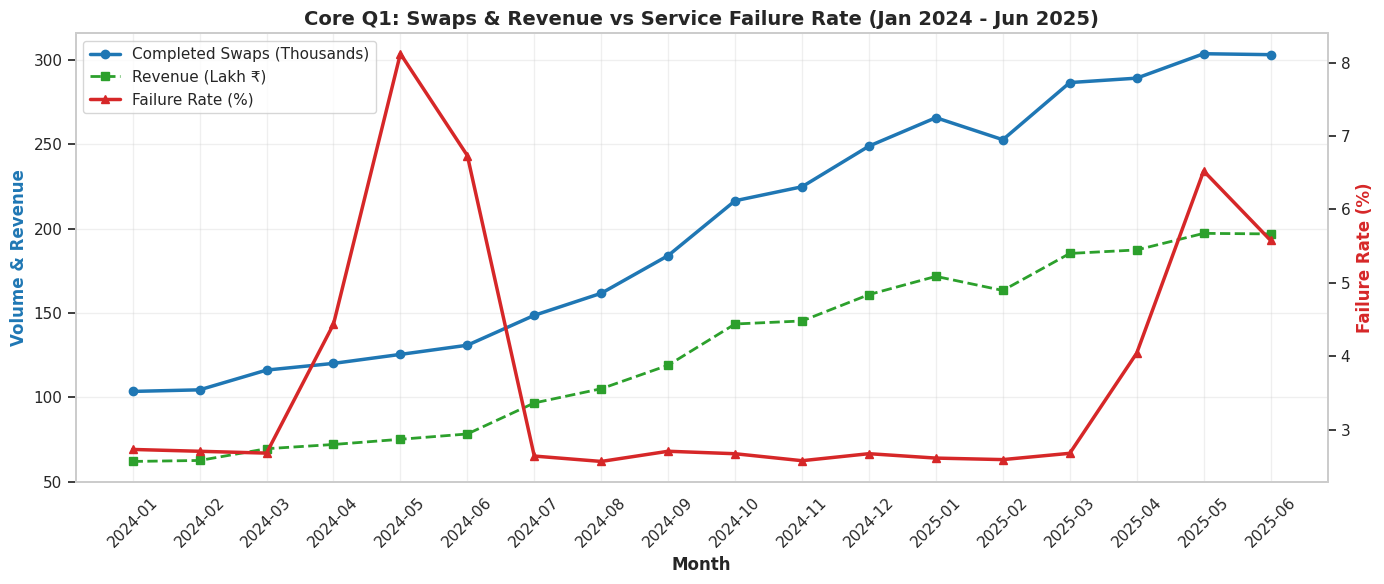

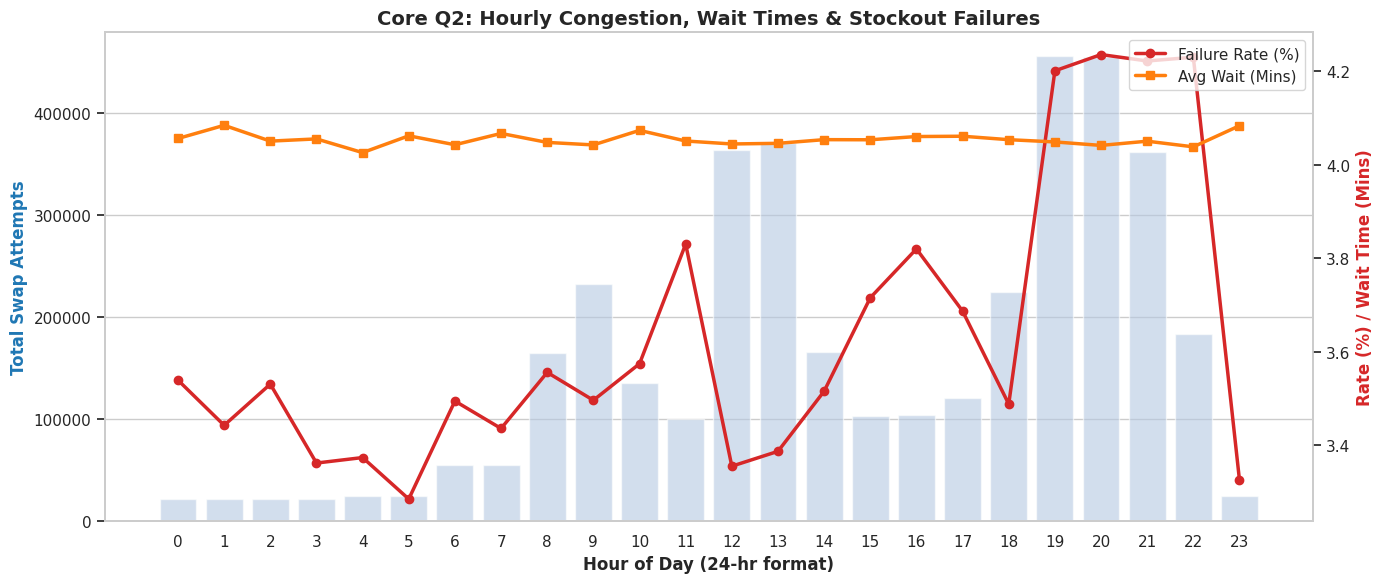


 Visualizations saved: 'q1_network_trends.png' and 'q2_hourly_congestion.png'


In [ ]:
# CELL 3: CORE QUESTION 1 & 2 — NETWORK PERFORMANCE & SERVICE FAILURE ANALYSIS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("⏳ Merging reference tables and calculating monthly network KPIs...")

# 1. Merge Swap Events with Station & Rider Metadata
df_merged = df_swaps.merge(
    df_stations[['station_id', 'city', 'location_type', 'charger_generation', 'grid_tariff_inr_kwh']],
    on='station_id',
    how='left'
).merge(
    df_riders[['rider_id', 'vehicle_class', 'plan_type', 'home_city_cleaned']],
    on='rider_id',
    how='left'
)

# 2. Derive Financial & Operational Flags
df_merged['is_completed'] = df_merged['event_type'] == 'swap_completed'
df_merged['is_failed'] = df_merged['event_type'].isin(['failed_no_charged_battery', 'failed_system_error'])
df_merged['is_abandoned'] = df_merged['event_type'] == 'abandoned_queue'

# Energy cost = grid energy used * local station electricity tariff
df_merged['energy_cost_inr'] = df_merged['energy_to_recharge_kwh'] * df_merged['grid_tariff_inr_kwh']
df_merged['contribution_margin_inr'] = df_merged['amount_charged_inr'] - df_merged['energy_cost_inr']

# 3. Monthly Aggregation (Question 1)
df_merged['month_str'] = df_merged['year_month'].astype(str)
monthly_summary = df_merged.groupby('month_str').agg(
    total_attempts=('event_id', 'count'),
    completed_swaps=('is_completed', 'sum'),
    failed_swaps=('is_failed', 'sum'),
    abandoned_swaps=('is_abandoned', 'sum'),
    total_revenue=('amount_charged_inr', 'sum'),
    total_margin=('contribution_margin_inr', 'sum'),
    avg_queue_sec=('queue_wait_sec', 'mean')
).reset_index()

monthly_summary['failure_rate_pct'] = (monthly_summary['failed_swaps'] / monthly_summary['total_attempts']) * 100
monthly_summary['margin_per_swap_inr'] = monthly_summary['total_margin'] / monthly_summary['completed_swaps']

# ------------------------------------------------------------------------------
# VISUALIZATION 1: Macro Network Trends (Question 1)
# ------------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(monthly_summary['month_str'], monthly_summary['completed_swaps'] / 1000,
         color='#1f77b4', marker='o', linewidth=2.5, label='Completed Swaps (Thousands)')
ax1.plot(monthly_summary['month_str'], monthly_summary['total_revenue'] / 100000,
         color='#2ca02c', marker='s', linewidth=2, linestyle='--', label='Revenue (Lakh ₹)')
ax1.set_xlabel('Month', fontweight='bold')
ax1.set_ylabel('Volume & Revenue', fontweight='bold', color='#1f77b4')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Twin axis for Failure Rate
ax2 = ax1.twinx()
ax2.plot(monthly_summary['month_str'], monthly_summary['failure_rate_pct'],
         color='#d62728', marker='^', linewidth=2.5, label='Failure Rate (%)')
ax2.set_ylabel('Failure Rate (%)', fontweight='bold', color='#d62728')
ax2.grid(False)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Core Q1: Swaps & Revenue vs Service Failure Rate (Jan 2024 - Jun 2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q1_network_trends.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# VISUALIZATION 2: Hour-of-Day Congestion & Failures (Question 2)
# ------------------------------------------------------------------------------
hourly_profile = df_merged.groupby('event_hour').agg(
    total_swaps=('event_id', 'count'),
    failure_rate=('is_failed', lambda x: (x.sum() / len(x)) * 100),
    abandon_rate=('is_abandoned', lambda x: (x.sum() / len(x)) * 100),
    avg_wait_min=('queue_wait_sec', lambda x: x.mean() / 60)
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=hourly_profile, x='event_hour', y='total_swaps', color='#aec7e8', alpha=0.6, ax=ax1)
ax1.set_ylabel('Total Swap Attempts', fontweight='bold', color='#1f77b4')
ax1.set_xlabel('Hour of Day (24-hr format)', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(hourly_profile['event_hour'], hourly_profile['failure_rate'], color='#d62728', marker='o', linewidth=2.5, label='Failure Rate (%)')
ax2.plot(hourly_profile['event_hour'], hourly_profile['avg_wait_min'], color='#ff7f0e', marker='s', linewidth=2.5, label='Avg Wait (Mins)')
ax2.set_ylabel('Rate (%) / Wait Time (Mins)', fontweight='bold', color='#d62728')
ax2.legend(loc='upper right')
ax2.grid(False)

plt.title('Core Q2: Hourly Congestion, Wait Times & Stockout Failures', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q2_hourly_congestion.png', dpi=300)
plt.show()

print("\n Visualizations saved: 'q1_network_trends.png' and 'q2_hourly_congestion.png'")


⏳ Analyzing Station Hardware Generations and Battery Supplier Health...


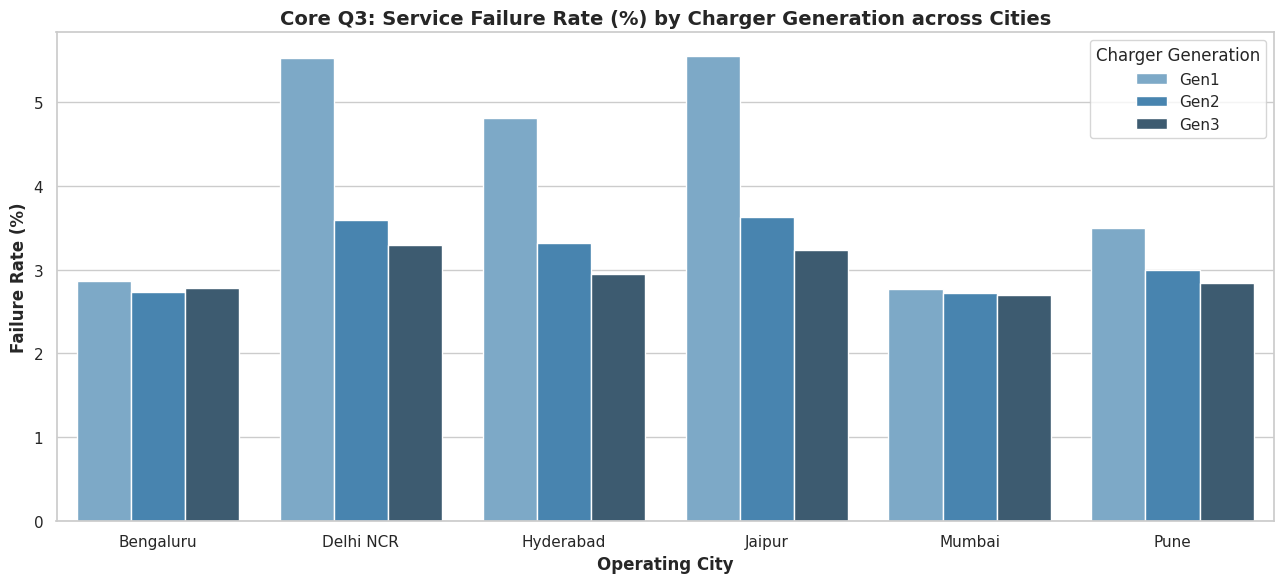


--- Battery Supplier Performance Summary ---
supplier  total_packs  avg_initial_soh  avg_current_soh  avg_soh_loss  avg_purchase_cost
  Amptek         1307        99.194415        81.005203     18.189212       37724.116297
 Cellora         3555        99.183769        80.929030     18.254740       37245.407876
   Kyron         1638        99.205128        63.747436     35.457692       37532.742979


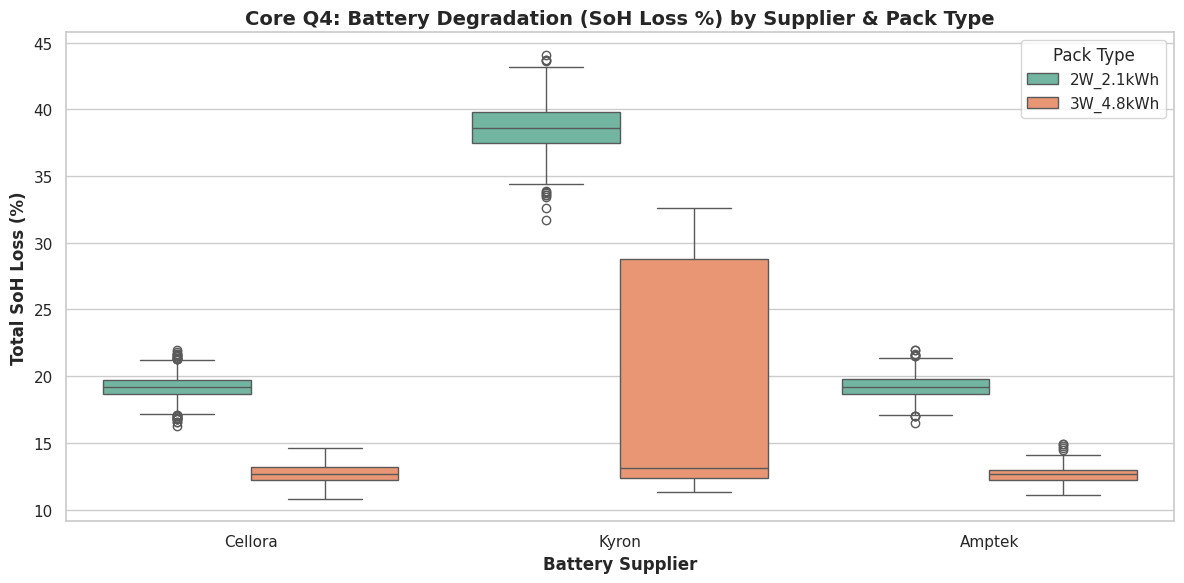


 Visualizations saved: 'q3_station_generation_perf.png' and 'q4_battery_degradation.png'


In [ ]:
# CELL 4: CORE QUESTIONS 3 & 4 — HARDWARE, STATIONS & BATTERY SUPPLIERS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("⏳ Analyzing Station Hardware Generations and Battery Supplier Health...")

# ------------------------------------------------------------------------------
# 1. QUESTION 3: Station Charger Generations & Expansion Waves
# ------------------------------------------------------------------------------
stn_perf = df_merged.groupby(['city', 'charger_generation']).agg(
    total_attempts=('event_id', 'count'),
    failed_attempts=('is_failed', 'sum'),
    avg_wait_sec=('queue_wait_sec', 'mean')
).reset_index()

stn_perf['failure_rate_pct'] = (stn_perf['failed_attempts'] / stn_perf['total_attempts']) * 100

# Plot 3: Failure Rate by Charger Generation across Cities
plt.figure(figsize=(13, 6))
sns.barplot(
    data=stn_perf,
    x='city',
    y='failure_rate_pct',
    hue='charger_generation',
    palette='Blues_d'
)
plt.title('Core Q3: Service Failure Rate (%) by Charger Generation across Cities', fontsize=14, fontweight='bold')
plt.xlabel('Operating City', fontweight='bold')
plt.ylabel('Failure Rate (%)', fontweight='bold')
plt.legend(title='Charger Generation', loc='upper right')
plt.tight_layout()
plt.savefig('q3_station_generation_perf.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# 2. QUESTION 4: Battery Degradation by Supplier (Cellora vs Amptek vs Kyron)
# ------------------------------------------------------------------------------
# Calculate degradation: Initial State of Health (SoH) vs Current SoH
df_batteries['soh_loss_pct'] = df_batteries['initial_soh_pct'] - df_batteries['current_soh_pct']

# Aggregate battery stats by supplier and pack type
supplier_summary = df_batteries.groupby('supplier').agg(
    total_packs=('battery_id', 'count'),
    avg_initial_soh=('initial_soh_pct', 'mean'),
    avg_current_soh=('current_soh_pct', 'mean'),
    avg_soh_loss=('soh_loss_pct', 'mean'),
    avg_purchase_cost=('purchase_cost_inr', 'mean')
).reset_index()

print("\n--- Battery Supplier Performance Summary ---")
print(supplier_summary.to_string(index=False))

# Plot 4: State of Health Degradation Distribution
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_batteries,
    x='supplier',
    y='soh_loss_pct',
    hue='pack_type',
    palette='Set2'
)
plt.title('Core Q4: Battery Degradation (SoH Loss %) by Supplier & Pack Type', fontsize=14, fontweight='bold')
plt.xlabel('Battery Supplier', fontweight='bold')
plt.ylabel('Total SoH Loss (%)', fontweight='bold')
plt.legend(title='Pack Type', loc='upper right')
plt.tight_layout()
plt.savefig('q4_battery_degradation.png', dpi=300)
plt.show()

print("\n Visualizations saved: 'q3_station_generation_perf.png' and 'q4_battery_degradation.png'")

⏳ Analyzing Fleet Partner Margins and Rider Retention Drivers...

--- Top Partners by Volume and Contribution Margin ---
      partner_name  total_swaps  gross_revenue  total_energy_cost   net_margin  avg_margin_per_swap
Independent Riders      1218359    83104666.00       2.213612e+07 6.096854e+07            50.041527
           ZipDrop       549249    28599387.20       1.051329e+07 1.808610e+07            32.928774
          FeastFly       516267    32021758.50       9.402017e+06 2.261974e+07            43.814036
        ParcelNest       296179    16738485.50       5.369812e+06 1.136867e+07            38.384470
        Swiggle Go       237593    14090186.10       4.363139e+06 9.727047e+06            40.939955
          CargoTuk       131323    13061517.60       5.357558e+06 7.703959e+06            58.664204
         QuickCart       127928     7932536.45       2.288086e+06 5.644451e+06            44.122090
         RideMitra       119472     7492715.50       2.143080e+06 5.349635e+06 

/tmp/ipykernel_1009/4206222829.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_partners, x='partner_name', y='avg_margin_per_swap', palette='crest')


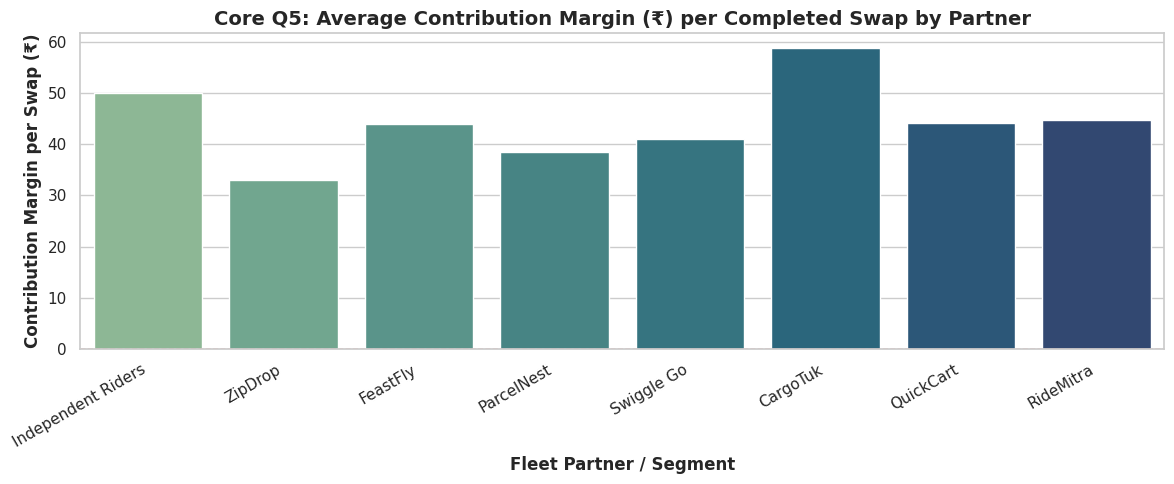


--- Churn Rate by First Swap Experience ---
     first_swap_status  total_new_riders  churned_riders  churn_rate_pct
       Abandoned Queue               345               2        0.579710
             Completed             18799              88        0.468110
Failed (No Batt/Error)               797               1        0.125471


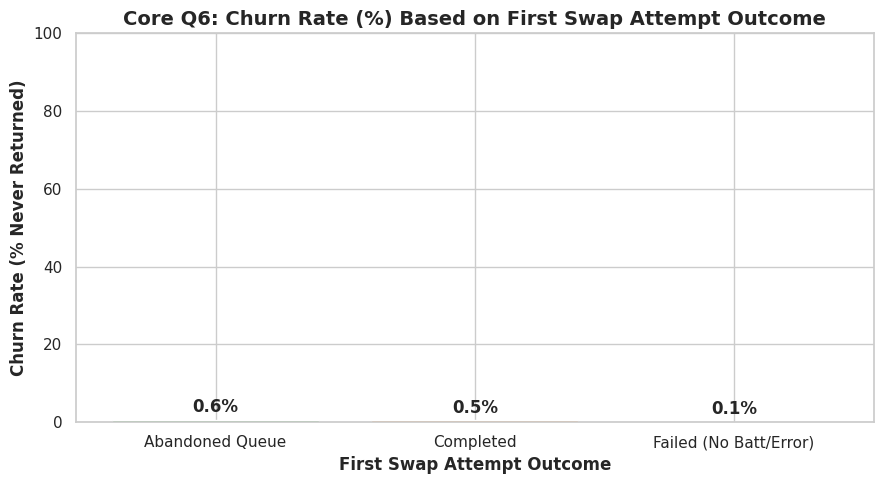


 Visualizations saved: 'q5_partner_margins.png' and 'q6_churn_root_cause.png'


In [ ]:
# CELL 5: CORE QUESTIONS 5 & 6 — PARTNER ECONOMICS & RIDER CHURN ROOT CAUSE
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("⏳ Analyzing Fleet Partner Margins and Rider Retention Drivers...")

# 1. Ensure partner_id is present by bringing it from df_riders
if 'partner_id' not in df_merged.columns:
    df_merged = df_merged.merge(df_riders[['rider_id', 'partner_id']], on='rider_id', how='left')

# ------------------------------------------------------------------------------
# QUESTION 5: Fleet Partner Contribution Margins
# ------------------------------------------------------------------------------
# Merge fleet partner metadata
df_fleet_perf = df_merged.merge(
    df_fleet[['partner_id', 'partner_name', 'partner_segment', 'discount_pct']],
    on='partner_id',
    how='left'
)

# Label independent riders
df_fleet_perf['partner_name'] = df_fleet_perf['partner_name'].fillna('Independent Riders')

partner_margins = df_fleet_perf[df_fleet_perf['is_completed']].groupby('partner_name').agg(
    total_swaps=('event_id', 'count'),
    gross_revenue=('amount_charged_inr', 'sum'),
    total_energy_cost=('energy_cost_inr', 'sum'),
    net_margin=('contribution_margin_inr', 'sum'),
    avg_margin_per_swap=('contribution_margin_inr', 'mean')
).reset_index().sort_values(by='total_swaps', ascending=False)

print("\n--- Top Partners by Volume and Contribution Margin ---")
print(partner_margins.head(10).to_string(index=False))

# Plot 5: Contribution Margin per Swap across top partners
plt.figure(figsize=(12, 5))
top_partners = partner_margins.head(8)
sns.barplot(data=top_partners, x='partner_name', y='avg_margin_per_swap', palette='crest')
plt.title('Core Q5: Average Contribution Margin (₹) per Completed Swap by Partner', fontsize=14, fontweight='bold')
plt.xlabel('Fleet Partner / Segment', fontweight='bold')
plt.ylabel('Contribution Margin per Swap (₹)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('q5_partner_margins.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# QUESTION 6: Root Cause Analysis of Rider Retention / Churn
# ------------------------------------------------------------------------------
# Determine each rider's very first swap experience
first_swaps = df_swaps.sort_values('event_ts').groupby('rider_id').first().reset_index()

first_swaps['first_swap_status'] = np.where(
    first_swaps['event_type'] == 'swap_completed', 'Completed',
    np.where(first_swaps['event_type'] == 'abandoned_queue', 'Abandoned Queue', 'Failed (No Batt/Error)')
)

# Total lifetime swaps per rider
rider_lifetime_swaps = df_swaps.groupby('rider_id')['event_id'].count().rename('total_lifetime_swaps')
first_swaps = first_swaps.merge(rider_lifetime_swaps, on='rider_id', how='left')

# Churn definition: Riders who attempted once and never completed another swap
first_swaps['is_churned_1st_attempt'] = first_swaps['total_lifetime_swaps'] == 1

churn_analysis = first_swaps.groupby('first_swap_status').agg(
    total_new_riders=('rider_id', 'count'),
    churned_riders=('is_churned_1st_attempt', 'sum')
).reset_index()

churn_analysis['churn_rate_pct'] = (churn_analysis['churned_riders'] / churn_analysis['total_new_riders']) * 100

print("\n--- Churn Rate by First Swap Experience ---")
print(churn_analysis.to_string(index=False))

# Plot 6: Impact of First Experience on Rider Churn
plt.figure(figsize=(9, 5))
bars = plt.bar(churn_analysis['first_swap_status'], churn_analysis['churn_rate_pct'], color=['#2ca02c', '#ff7f0e', '#d62728'])
plt.title('Core Q6: Churn Rate (%) Based on First Swap Attempt Outcome', fontsize=14, fontweight='bold')
plt.xlabel('First Swap Attempt Outcome', fontweight='bold')
plt.ylabel('Churn Rate (% Never Returned)', fontweight='bold')
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('q6_churn_root_cause.png', dpi=300)
plt.show()

print("\n Visualizations saved: 'q5_partner_margins.png' and 'q6_churn_root_cause.png'")

⏳ Calculating Monthly Signup Cohort Retention & Ticket Analysis...


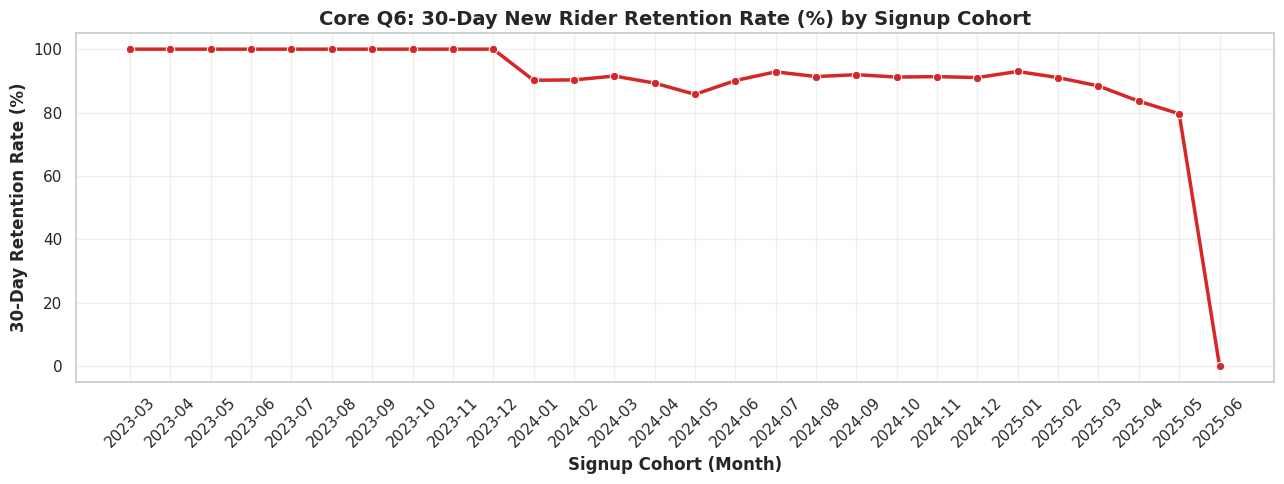


--- Support Ticket Category Breakdown ---
            category  ticket_count       pct
no_battery_available         11647 26.470455
               other          9484 21.554545
           low_range          6636 15.081818
           app_issue          5787 13.152273
          long_queue          5731 13.025000
     billing_dispute          4715 10.715909


/tmp/ipykernel_1009/1002039150.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ticket_summary.head(6), x='ticket_count', y='category', palette='magma')


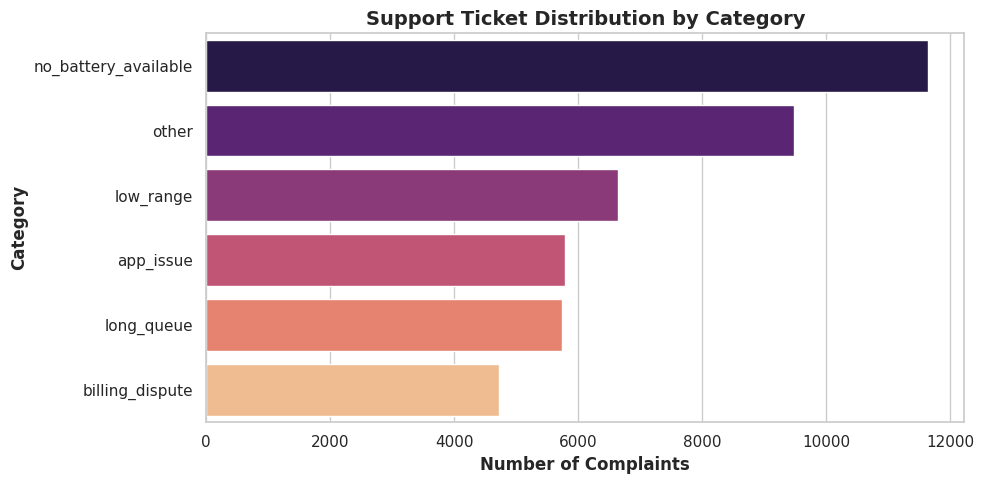


 Visualizations saved: 'q6_cohort_retention_trend.png' and 'support_tickets_breakdown.png'


In [ ]:
# CELL 6: COHORT RETENTION & SUPPORT TICKET ANALYSIS (CLOSING Q6 & OPTIONAL)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("⏳ Calculating Monthly Signup Cohort Retention & Ticket Analysis...")

# 1. Parse signup date and assign signup cohort
df_riders['signup_dt'] = pd.to_datetime(df_riders['signup_date'])
df_riders['signup_cohort'] = df_riders['signup_dt'].dt.to_period('M').astype(str)

# 2. Get last active swap date per rider
last_swaps = df_swaps.groupby('rider_id')['event_ts'].max().reset_index()
last_swaps.columns = ['rider_id', 'last_swap_ts']

# Calculate rider tenure in days
df_rider_activity = df_riders.merge(last_swaps, on='rider_id', how='left')
df_rider_activity['tenure_days'] = (df_rider_activity['last_swap_ts'] - df_rider_activity['signup_dt']).dt.days

# A rider is retained beyond 30 days if tenure >= 30 days
df_rider_activity['retained_30d'] = df_rider_activity['tenure_days'] >= 30

cohort_retention = df_rider_activity.groupby('signup_cohort').agg(
    total_signups=('rider_id', 'count'),
    retained_30d=('retained_30d', 'sum')
).reset_index()

cohort_retention['retention_rate_30d_pct'] = (cohort_retention['retained_30d'] / cohort_retention['total_signups']) * 100

# Plot 6A: 30-Day Retention Trend by Signup Cohort
plt.figure(figsize=(13, 5))
sns.lineplot(
    data=cohort_retention,
    x='signup_cohort',
    y='retention_rate_30d_pct',
    marker='o',
    color='#d62728',
    linewidth=2.5
)
plt.title('Core Q6: 30-Day New Rider Retention Rate (%) by Signup Cohort', fontsize=14, fontweight='bold')
plt.xlabel('Signup Cohort (Month)', fontweight='bold')
plt.ylabel('30-Day Retention Rate (%)', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q6_cohort_retention_trend.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# 3. Support Tickets Analysis: Complaint Categories
# ------------------------------------------------------------------------------
ticket_summary = df_tickets['category'].value_counts().reset_index()
ticket_summary.columns = ['category', 'ticket_count']
ticket_summary['pct'] = (ticket_summary['ticket_count'] / len(df_tickets)) * 100

print("\n--- Support Ticket Category Breakdown ---")
print(ticket_summary.to_string(index=False))

# Plot 6B: Top Complaint Categories
plt.figure(figsize=(10, 5))
sns.barplot(data=ticket_summary.head(6), x='ticket_count', y='category', palette='magma')
plt.title('Support Ticket Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Number of Complaints', fontweight='bold')
plt.ylabel('Category', fontweight='bold')
plt.tight_layout()
plt.savefig('support_tickets_breakdown.png', dpi=300)
plt.show()

print("\n Visualizations saved: 'q6_cohort_retention_trend.png' and 'support_tickets_breakdown.png'")